<>:149: SyntaxWarning: invalid escape sequence '\m'
<>:149: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Диана\AppData\Local\Temp\ipykernel_1936\1217851933.py:149: SyntaxWarning: invalid escape sequence '\m'
  f'$\mu$ = {mu}')


МОДЕЛИРОВАНИЕ АНТИСЕГНЕТОЭЛЕКТРИЧЕСКОЙ ПЕТЛИ ГИСТЕРЕЗИСА
Основано на статье: Misirlioglu et al., Appl. Phys. Lett. 91, 202905 (2007)
Параметры модели:
J_FE = 0.1032, J_AFE = -0.2064
J_FE/J_AFE = -0.50
J_FE/kT = 4, kT = 0.026
μ = 0.5
Размер решетки: 30x30
Максимальное поле: E_max = 0.7

Начальная конфигурация установлена
Начальная поляризация: 0.0000
Прямой ход гистерезиса...
  E =  -0.70, P = -0.3044
  E =  -0.42, P = -0.5000
  E =  -0.13, P = -0.1378
  E =   0.15, P =  0.0444
  E =   0.43, P =  0.5000
Обратный ход гистерезиса...
  E =   0.70, P =  0.5000
  E =   0.42, P =  0.5000
  E =   0.13, P =  0.1233
  E =  -0.15, P = -0.0511
  E =  -0.43, P = -0.5000


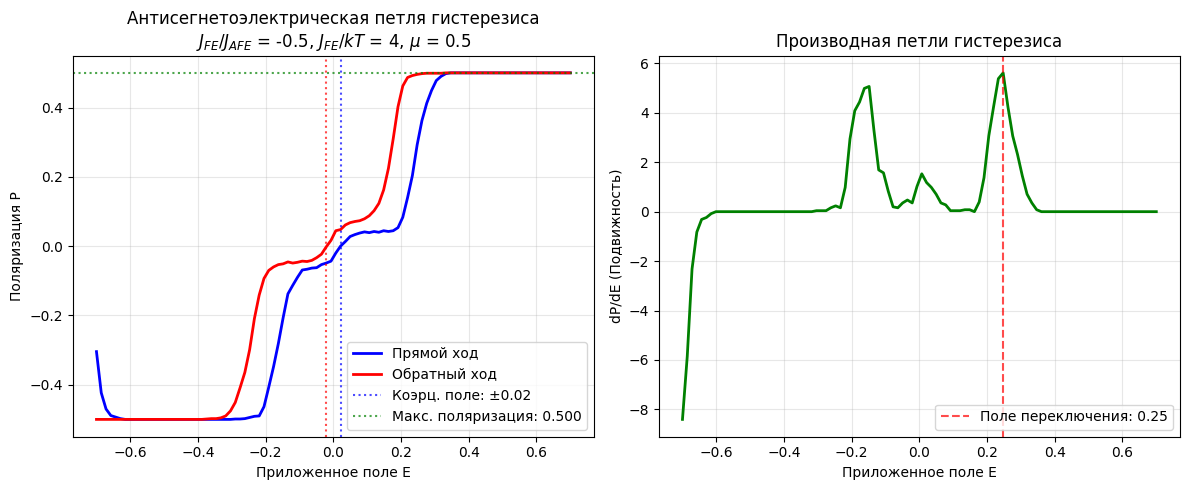


Характеристики петли гистерезиса:
Коэрцитивное поле (прямой ход): 0.021
Коэрцитивное поле (обратный ход): -0.021
Максимальная поляризация: 0.500
Остаточная поляризация: 0.500
Поле переключения: 0.247


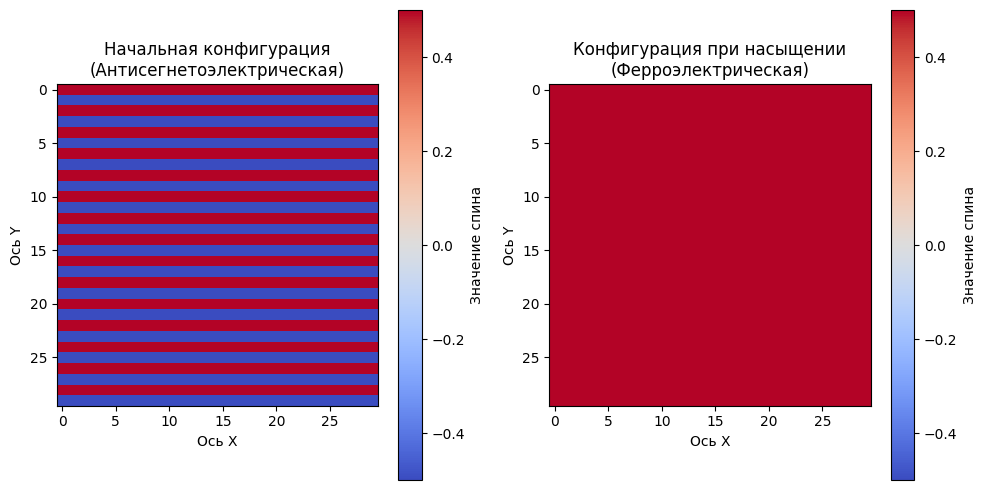


СИМУЛЯЦИЯ ЗАВЕРШЕНА!


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Параметры модели из статьи для типичной антисегнетоэлектрической петли
J_FE = 0.1032          # Ферроэлектрическая константа взаимодействия
J_AFE = -0.2064         # Антиферроэлектрическая константа взаимодействия  
J_FE_kT = 4        # Отношение J_FE/kT
mu = 0.5             # Величина дипольного момента
size = 30            # Размер решетки 30x30
E_max = 0.7            # Максимальное поле
num_points = 100     # Количество точек на полупериоде
mc_steps_per_point = 800  # Шагов Монте-Карло на точку

def initialize_spins(size):
    """Инициализация антиферроэлектрической конфигурации (колонки)"""
    spins = np.zeros((size, size))
    for i in range(size):
        for j in range(size):
            # Чередование колонок: четные +0.5, нечетные -0.5
            if i % 2 == 0:
                spins[i, j] = 0.5
            else:
                spins[i, j] = -0.5
    return spins

def calculate_energy_difference(spins, i, j, E_app, size, J_FE, J_AFE, mu, kT):
    """Расчет разности энергии при перевороте спина"""
    current_spin = spins[i, j]
    new_spin = -current_spin
    energy_diff = 0
    
    # Ферроэлектрическое взаимодействие (вертикальное) - свободные границы по Y
    if j > 0:  # Верхний сосед
        energy_diff += -J_FE * (new_spin - current_spin) * spins[i, j-1]
    if j < size - 1:  # Нижний сосед
        energy_diff += -J_FE * (new_spin - current_spin) * spins[i, j+1]
    
    # Антиферроэлектрическое взаимодействие (горизонтальное) - периодические границы по X
    left_i = (i - 1) % size
    right_i = (i + 1) % size
    energy_diff += -J_AFE * (new_spin - current_spin) * spins[left_i, j]
    energy_diff += -J_AFE * (new_spin - current_spin) * spins[right_i, j]
    
    # Энергия от внешнего поля
    energy_diff += -2 * E_app * mu * (new_spin - current_spin)
    
    return energy_diff

def glauber_probability(delta_energy, kT):
    """Вероятность переворота спина по формуле Глаубера из статьи"""
    if delta_energy < 0:
        return 1.0
    else:
        return 0.5 * (1 - np.tanh(delta_energy / (2 * kT)))

def mc_step(spins, E_app, size, J_FE, J_AFE, mu, kT, steps=1000):
    """Один шаг Монте-Карло"""
    for _ in range(steps):
        # Случайный выбор сайта
        i = random.randint(0, size-1)
        j = random.randint(0, size-1)
        
        # Расчет разности энергии
        delta_energy = calculate_energy_difference(spins, i, j, E_app, size, J_FE, J_AFE, mu, kT)
        
        # Принятие решения о перевороте спина
        if delta_energy < 0:
            spins[i, j] = -spins[i, j]
        else:
            P = glauber_probability(delta_energy, kT)
            if random.random() < P:
                spins[i, j] = -spins[i, j]
    
    return spins

def calculate_polarization(spins):
    """Расчет средней поляризации"""
    return np.mean(spins)

def simulate_hysteresis():
    """Симуляция полной петли гистерезиса"""
    # Вычисляем kT из J_FE/kT
    kT = J_FE / J_FE_kT
    
    print("Параметры модели:")
    print(f"J_FE = {J_FE}, J_AFE = {J_AFE}")
    print(f"J_FE/J_AFE = {J_FE/J_AFE:.2f}")
    print(f"J_FE/kT = {J_FE_kT}, kT = {kT:.3f}")
    print(f"μ = {mu}")
    print(f"Размер решетки: {size}x{size}")
    print(f"Максимальное поле: E_max = {E_max}")
    print()
    
    # Инициализация спинов
    spins = initialize_spins(size)
    initial_spins = spins.copy()
    
    print("Начальная конфигурация установлена")
    print(f"Начальная поляризация: {calculate_polarization(spins):.4f}")
    
    # Прямой ход: от -E_max до E_max
    print("Прямой ход гистерезиса...")
    E_fields_forward = np.linspace(-E_max, E_max, num_points)
    polarization_forward = []
    
    for idx, E in enumerate(E_fields_forward):
        spins = mc_step(spins, E, size, J_FE, J_AFE, mu, kT, mc_steps_per_point)
        polarization_forward.append(calculate_polarization(spins))
        
        if idx % 20 == 0:
            print(f"  E = {E:6.2f}, P = {polarization_forward[-1]:7.4f}")
    
    # Сохраняем конфигурацию после прямого хода
    spins_after_forward = spins.copy()
    
    # Обратный ход: от E_max до -E_max
    print("Обратный ход гистерезиса...")
    E_fields_reverse = np.linspace(E_max, -E_max, num_points)
    polarization_reverse = []
    
    for idx, E in enumerate(E_fields_reverse):
        spins = mc_step(spins, E, size, J_FE, J_AFE, mu, kT, mc_steps_per_point)
        polarization_reverse.append(calculate_polarization(spins))
        
        if idx % 20 == 0:
            print(f"  E = {E:6.2f}, P = {polarization_reverse[-1]:7.4f}")
    
    # Восстанавливаем начальное состояние для визуализации
    spins_initial = initial_spins.copy()
    
    return (E_fields_forward, polarization_forward, 
            E_fields_reverse, polarization_reverse,
            spins_initial, spins_after_forward)

def plot_hysteresis(E_forward, P_forward, E_reverse, P_reverse):
    """Построение графика петли гистерезиса"""
    plt.figure(figsize=(12, 5))
    
    # Петля гистерезиса
    plt.subplot(1, 2, 1)
    plt.plot(E_forward, P_forward, 'b-', linewidth=2, label='Прямой ход')
    plt.plot(E_reverse, P_reverse, 'r-', linewidth=2, label='Обратный ход')
    plt.xlabel('Приложенное поле E')
    plt.ylabel('Поляризация P')
    plt.title(f'Антисегнетоэлектрическая петля гистерезиса\n'
              f'$J_{{FE}}/J_{{AFE}}$ = {J_FE/J_AFE:.1f}, '
              f'$J_{{FE}}/kT$ = {J_FE_kT}, '
              f'$\mu$ = {mu}')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Расчет характеристик
    coercive_forward = E_forward[np.argmin(np.abs(P_forward))]
    coercive_reverse = E_reverse[np.argmin(np.abs(P_reverse))]
    max_polarization = max(max(P_forward), max(P_reverse))
    
    plt.axvline(x=coercive_forward, color='blue', linestyle=':', alpha=0.7, 
                label=f'Коэрц. поле: ±{abs(coercive_forward):.2f}')
    plt.axvline(x=coercive_reverse, color='red', linestyle=':', alpha=0.7)
    plt.axhline(y=max_polarization, color='green', linestyle=':', alpha=0.7,
                label=f'Макс. поляризация: {max_polarization:.3f}')
    plt.legend()
    
    # График производной (подвижность)
    plt.subplot(1, 2, 2)
    dP_dE = np.gradient(P_forward, E_forward)
    plt.plot(E_forward, dP_dE, 'g-', linewidth=2)
    plt.xlabel('Приложенное поле E')
    plt.ylabel('dP/dE (Подвижность)')
    plt.title('Производная петли гистерезиса')
    plt.grid(True, alpha=0.3)
    
    # Показать поле переключения
    switch_field_idx = np.argmax(dP_dE)
    switch_field = E_forward[switch_field_idx]
    plt.axvline(x=switch_field, color='red', linestyle='--', alpha=0.7,
                label=f'Поле переключения: {switch_field:.2f}')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Вывод характеристик
    print("\nХарактеристики петли гистерезиса:")
    print(f"Коэрцитивное поле (прямой ход): {coercive_forward:.3f}")
    print(f"Коэрцитивное поле (обратный ход): {coercive_reverse:.3f}")
    print(f"Максимальная поляризация: {max_polarization:.3f}")
    print(f"Остаточная поляризация: {P_forward[-1]:.3f}")
    print(f"Поле переключения: {switch_field:.3f}")

def visualize_spin_configurations(spins_initial, spins_after_forward):
    """Визуализация конфигураций спинов"""
    plt.figure(figsize=(10, 5))
    
    # Начальная конфигурация
    plt.subplot(1, 2, 1)
    plt.imshow(spins_initial, cmap='coolwarm', vmin=-0.5, vmax=0.5, interpolation='none')
    plt.colorbar(label='Значение спина')
    plt.title('Начальная конфигурация\n(Антисегнетоэлектрическая)')
    plt.xlabel('Ось X')
    plt.ylabel('Ось Y')
    
    # Конфигурация после насыщения
    plt.subplot(1, 2, 2)
    plt.imshow(spins_after_forward, cmap='coolwarm', vmin=-0.5, vmax=0.5, interpolation='none')
    plt.colorbar(label='Значение спина')
    plt.title('Конфигурация при насыщении\n(Ферроэлектрическая)')
    plt.xlabel('Ось X')
    plt.ylabel('Ось Y')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    print("=" * 70)
    print("МОДЕЛИРОВАНИЕ АНТИСЕГНЕТОЭЛЕКТРИЧЕСКОЙ ПЕТЛИ ГИСТЕРЕЗИСА")
    print("Основано на статье: Misirlioglu et al., Appl. Phys. Lett. 91, 202905 (2007)")
    print("=" * 70)
    
    # Запуск симуляции
    results = simulate_hysteresis()
    E_forward, P_forward, E_reverse, P_reverse, spins_initial, spins_after_forward = results
    
    # Построение графиков
    plot_hysteresis(E_forward, P_forward, E_reverse, P_reverse)
    
    # Визуализация конфигураций
    visualize_spin_configurations(spins_initial, spins_after_forward)
    
    print("\n" + "=" * 70)
    print("СИМУЛЯЦИЯ ЗАВЕРШЕНА!")
    print("=" * 70)